### Modeling
This notebook focuses on the modeling phase of the NYC 311 complaint-resolution project. The goal is to compare several classification models for predicting whether a complaint will take longer than one week to resolve.

The analysis uses `pandas` and `numpy` for data handling, `matplotlib` and `seaborn` for visualization, and `scikit-learn` / `xgboost` for model training and evaluation.

#### Import libraries and data
The processed training and test datasets created in the feature engineering notebook are loaded below. These files contain the final model-ready features and the binary target variable indicating whether a complaint took longer than one week to resolve.

In [1]:
# Core analysis libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Improve plot styling
sns.set()

# Show all columns during EDA
pd.set_option('display.max_columns', None)

In [2]:
# File paths
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
SRC_DIR = PROJECT_ROOT / "src"
DEPLOYMENT_DIR = PROJECT_ROOT / "deployment"

In [3]:
# Import model prep inputs
import sys
sys.path.append(str(SRC_DIR))

from feature_prep import prepare_model_input

In [4]:
# Load data parquet files
X_train = pd.read_parquet(DATA_DIR / "03_X_train_processed.parquet")
X_test = pd.read_parquet(DATA_DIR / "03_X_test_processed.parquet")

y_train = pd.read_parquet(DATA_DIR / "03_y_train.parquet").squeeze()
y_test = pd.read_parquet(DATA_DIR / "03_y_test.parquet").squeeze()

#### Details of data
The processed training and test datasets created in the feature engineering notebook are loaded below. These files contain the final model-ready features and the binary target variable indicating whether a complaint took longer than one week to resolve.

In [5]:
# Number of rows and columns
print("X_train cols, rows:", X_train.shape)
print("X_test cols, rows:", X_test.shape)
print("y_train cols, rows:", y_train.shape)
print("y_test cols, rows:", y_test.shape)

X_train cols, rows: (210461, 269)
X_test cols, rows: (52616, 269)
y_train cols, rows: (210461,)
y_test cols, rows: (52616,)


#### Check for class imbalance
Before training any models, the shape of each dataset is checked to confirm that the feature matrices and target vectors were loaded correctly and that the train/test split is consistent.

In [6]:
print("Target training class distribution:")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

Target training class distribution:
resolution_in_wk
0    200495
1      9966
Name: count, dtype: int64
resolution_in_wk
0    0.952647
1    0.047353
Name: proportion, dtype: float64


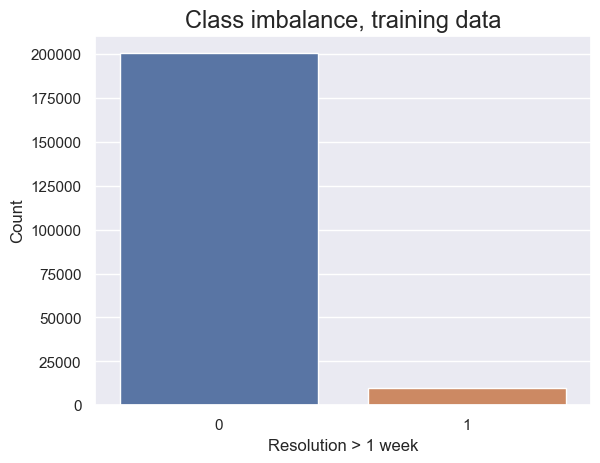

In [7]:
# Visualize training imbalance
sns.countplot(x=y_train, hue=y_train, legend=False)
plt.title("Class imbalance, training data", fontsize=17)
plt.xlabel("Resolution > 1 week")
plt.ylabel("Count")
plt.show()

In [8]:
print("Target testing class distribution:")
print(y_test.value_counts())
print(y_test.value_counts(normalize=True))

Target testing class distribution:
resolution_in_wk
0    50124
1     2492
Name: count, dtype: int64
resolution_in_wk
0    0.952638
1    0.047362
Name: proportion, dtype: float64


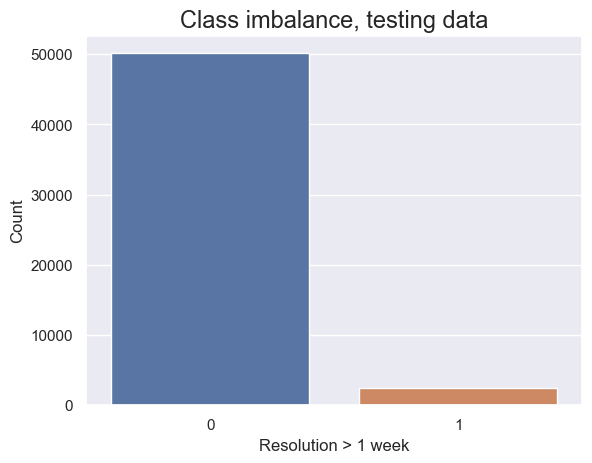

In [9]:
# Visualize testing imbalance
sns.countplot(x=y_test, hue=y_test, legend=False)
plt.title("Class imbalance, testing data", fontsize=17)
plt.xlabel("Resolution > 1 week")
plt.ylabel("Count")
plt.show()

#### Logistic Regression
Logistic Regression is used as the baseline model. It provides an interpretable linear benchmark and establishes a reference point for comparing more flexible non-linear models.

Because the target is imbalanced, the model uses `class_weight="balanced"` to give additional weight to the minority class during training.

In [10]:
# Import library and set config to display all model parameters
from sklearn.linear_model import LogisticRegression
from sklearn import set_config
set_config(print_changed_only=False, display="diagram")

In [11]:
# Run logistic regression
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg.fit(X_train, y_train)

LogisticRegression(C=1.0, class_weight='balanced', dual=False,
                   fit_intercept=True, intercept_scaling=1, l1_ratio=None,
                   max_iter=1000, multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [12]:
# Logistic regression predictions
y_pred_log_reg = log_reg.predict(X_test)

In [13]:
# Logistic regression probabilities
y_prob_log_reg = log_reg.predict_proba(X_test)[:,1]

In [14]:
# Import libabries for evaluation
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

In [15]:
# Logistic regression evaluation
log_reg_class_report = classification_report(y_test, y_pred_log_reg, output_dict=True)
pd.DataFrame(log_reg_class_report).round(3)

,0,1,accuracy,macro avg,weighted avg
precision,0.995,0.209,0.833,0.602,0.957
recall,0.829,0.910,0.833,0.869,0.833
f1-score,0.904,0.340,0.833,0.622,0.878
support,50124.000,2492.000,0.833,52616.000,52616.000


In [16]:
# ROC and AUC scores
roc_auc_log_reg = roc_auc_score(y_test, y_prob_log_reg).round(3)
pr_auc_log_reg = average_precision_score(y_test, y_prob_log_reg).round(3)

print("ROC-AUC:", roc_auc_log_reg)
print("PR-AUC:", pr_auc_log_reg)

ROC-AUC: 0.943
PR-AUC: 0.414


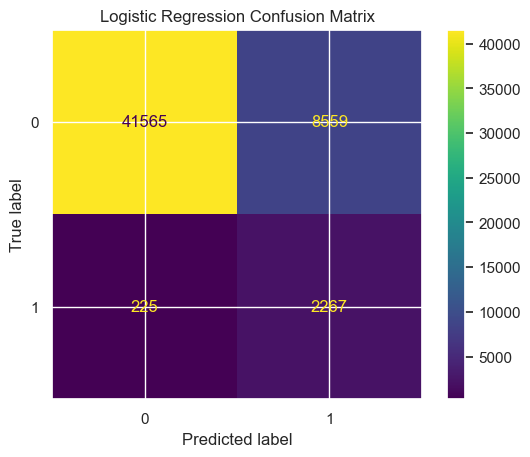

In [17]:
# Confusion matrix
log_reg_cf = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log_reg)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#### Random Forest Classifier
Random Forest is used as a tree-based ensemble model that can capture non-linear relationships and feature interactions more effectively than Logistic Regression.

This model serves as a strong benchmark for tabular data and is expected to perform well on structured service request data with engineered features.

In [18]:
# Import RF Classifier
from sklearn.ensemble import RandomForestClassifier

In [19]:
# Build classifier and fit
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight='balanced',
                       criterion='gini', max_depth=None, max_features='sqrt',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_samples_leaf=5,
                       min_samples_split=10, min_weight_fraction_leaf=0.0,
                       monotonic_cst=None, n_estimators=200, n_jobs=-1,
                       oob_score=False, random_state=42, verbose=0,
                       warm_start=False)

In [20]:
# Predictions
y_pred_rf = rf.predict(X_test)

In [21]:
# Probabilities
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [22]:
# ROC and AUC scores
roc_auc_score_rf = roc_auc_score(y_test, y_prob_rf).round(3)
pr_auc_rf = average_precision_score(y_test, y_prob_rf).round(3)

print("ROC-AUC:", roc_auc_score_rf)
print("PR-AUC:", pr_auc_rf)

ROC-AUC: 0.957
PR-AUC: 0.529


In [23]:
# RF Classifier class report
rf_class_report = classification_report(y_test, y_pred_rf, output_dict=True)
pd.DataFrame(rf_class_report).round(3)

,0,1,accuracy,macro avg,weighted avg
precision,0.994,0.291,0.892,0.642,0.960
recall,0.892,0.888,0.892,0.890,0.892
f1-score,0.940,0.438,0.892,0.689,0.916
support,50124.000,2492.000,0.892,52616.000,52616.000


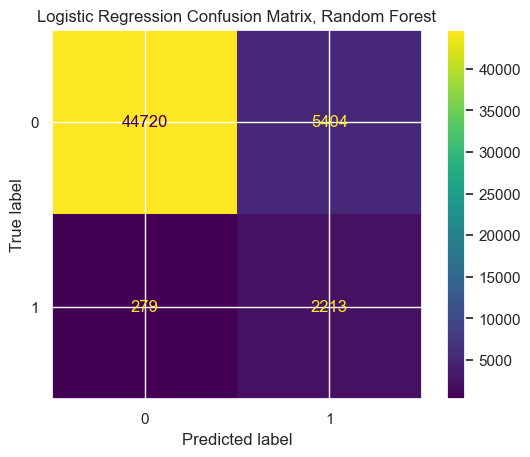

In [24]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.title("Logistic Regression Confusion Matrix, Random Forest")
plt.show()

#### XGBoost Classifier
XGBoost is included as a boosted tree model that often performs strongly on tabular machine learning problems. It is trained with class imbalance handling through `scale_pos_weight` and compared against both the linear baseline and the Random Forest model.

In [25]:
# Import library
from xgboost import XGBClassifier

In [26]:
# Build XGClassifier and fit
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [27]:
# Predictions
y_pred_xgb = xgb.predict(X_test)

In [28]:
# Probabilities
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

In [29]:
# ROC and AUC scores
roc_auc_score_xgb = roc_auc_score(y_test, y_prob_xgb).round(3)
pr_auc_xgb = average_precision_score(y_test, y_prob_xgb).round(3)

print("ROC-AUC:", roc_auc_score_xgb)
print("PR-AUC:", pr_auc_xgb)

ROC-AUC: 0.952
PR-AUC: 0.47


In [30]:
# XGB Classifier class report
xgb_class_report = classification_report(y_test, y_pred_xgb, output_dict=True)
pd.DataFrame(xgb_class_report).round(3)

,0,1,accuracy,macro avg,weighted avg
precision,0.997,0.219,0.837,0.608,0.960
recall,0.832,0.949,0.837,0.890,0.837
f1-score,0.907,0.356,0.837,0.631,0.881
support,50124.000,2492.000,0.837,52616.000,52616.000


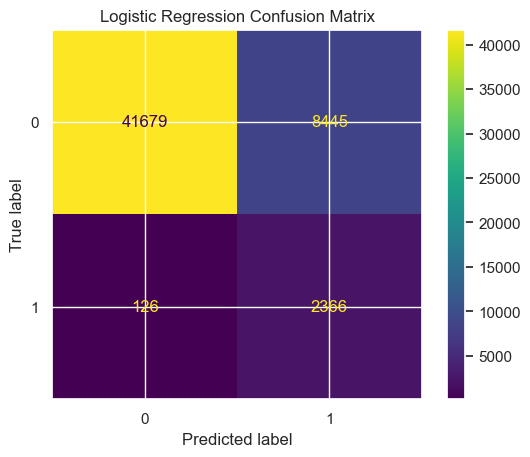

In [31]:
# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.title("Logistic Regression Confusion Matrix")
plt.show()

#### Plot ROC and PR-Curves

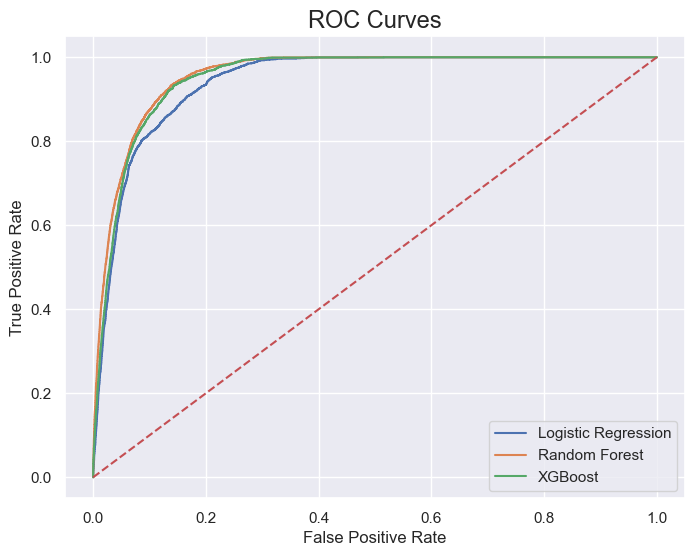

In [32]:
# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_log_reg)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot(fpr_xgb, tpr_xgb, label="XGBoost")

plt.plot([0,1], [0,1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves", fontsize=17)

plt.legend()

plt.show()

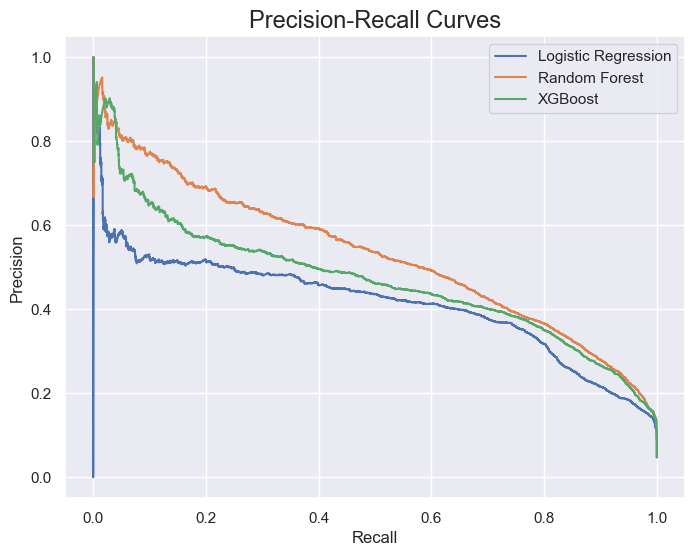

In [33]:
#P-R curves
prec_lr, rec_lr, _ = precision_recall_curve(y_test, y_prob_log_reg)
prec_rf, rec_rf, _ = precision_recall_curve(y_test, y_prob_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(y_test, y_prob_xgb)

plt.figure(figsize=(8,6))

plt.plot(rec_lr, prec_lr, label="Logistic Regression")
plt.plot(rec_rf, prec_rf, label="Random Forest")
plt.plot(rec_xgb, prec_xgb, label="XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves", fontsize=17)

plt.legend()

plt.show()

#### Compile metrics

In [34]:
# Logistic Regression metrics
log_reg_metrics = [
    "Logistic Regression",
    roc_auc_log_reg, 
    pr_auc_log_reg,
    round(log_reg_class_report["1"]["precision"], 3),
    round(log_reg_class_report["1"]["recall"], 3),
    round(log_reg_class_report["1"]["f1-score"], 3)
]

In [35]:
# Random Forest Metrics
rf_metrics = [
    "Random Forest Classifier",
    roc_auc_score_rf, 
    pr_auc_rf, 
    round(rf_class_report["1"]["precision"], 3),
    round(rf_class_report["1"]["recall"], 3),
    round(rf_class_report["1"]["f1-score"], 3)
]

In [36]:
# XGBoost Metrics
xgb_metrics = [
    "XGB Classifier",
    roc_auc_score_xgb, 
    pr_auc_xgb, 
    round(xgb_class_report["1"]["precision"], 3),
    round(xgb_class_report["1"]["recall"], 3),
    round(xgb_class_report["1"]["f1-score"], 3)
]

#### Model comparison table
Based on the model comparison results, Random Forest was selected as the final model. It delivered the strongest overall performance; the highest PR-AUC, ROC-AUC, precision, and F1 score, while XGBoost achieved the highest recall.

Because this project focuses on an imbalanced classification problem, PR-AUC is the primary model selection metric. Based on that criterion, Random Forest was selected as the final model for export and deployment.

In [37]:
# Make model comparison table
model_comparison = pd.DataFrame(columns=[
    "Model Name", 
    "ROC-AUC", 
    "PR-AUC",
    "Precision", 
    "Recall",
    "F1-Score"
])

model_comparison.loc[len(model_comparison)] = log_reg_metrics
model_comparison.loc[len(model_comparison)] = rf_metrics
model_comparison.loc[len(model_comparison)] = xgb_metrics

model_comparison.sort_values(by="PR-AUC", ascending=False)

,Model Name,ROC-AUC,PR-AUC,Precision,Recall,F1-Score
1,Random Forest Classifier,0.957,0.529,0.291,0.888,0.438
2,XGB Classifier,0.952,0.470,0.219,0.949,0.356
0,Logistic Regression,0.943,0.414,0.209,0.910,0.340


#### Export model
After selecting Random Forest as the final model, the model is saved as a serialized `.joblib` file. This exported model will be used in the next stage of the project for inference and AWS deployment.

In [39]:
# Save model
import joblib

joblib.dump(rf, MODELS_DIR / "nyc_info_random_forest_model.joblib")

['C:\\Users\\jac67\\Documents\\Data and Analytics\\Python\\nyc-311-project\\models\\nyc_info_random_forest_model.joblib']